In [13]:
import pandas as pd

file1 = pd.read_csv('IMPUTE_ANALYS.csv')
file2 = pd.read_csv('IMPUTE_ANALYS_2.csv')
file3 = pd.read_csv('IMPUTE_ANALYS_3.csv')
file = pd.concat([file1, file2, file3], axis = 0)

file.to_csv('analys_of_impute.csv', index = False)

In [15]:
custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
file = file.sort_values(
    by=['name_dataset', 'type_propusk', 'method_zapolnenia'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
)

In [16]:
file = file.reset_index(drop=True)
print(file.index)

RangeIndex(start=0, stop=6312, step=1)


In [17]:
file['method_zapolnenia'] = file['method_zapolnenia'].str[1:]


In [18]:
file['method_zapolnenia'] = file['method_zapolnenia'].replace({'MEAN_MOD': 'MEAN_MODE', 'MED_MOD': 'MEDIAN_MODE', 'NUL_MOD': 'NUL_MODE'})

In [19]:
file.head()

,type_propusk,method_zapolnenia,name_dataset,RMSE,MAE,R2,KL_divergence_median,KL_divergence_max,KS_statistic_median,KS_statistic_max,Wasserstein_2_median,Wasserstein_2_max,kl_w_vs_w_hat,ks_w_vs_w_hat,wasserstein_2_w_vs_w_hat,mean_ratio
0,MAR_5,KNN15,2dplanes_binclass_binaryClass.csv,0.184215,0.034117,0.950070,0.016393,0.020459,0.323931,0.331584,0.141456,0.181881,7.639535,0.778,0.012009,1.881590
1,MAR_5,MEAN_MODE,2dplanes_binclass_binaryClass.csv,0.260873,0.042362,0.899868,0.026755,0.043639,0.032575,0.033899,0.222430,0.318207,1.232431,0.782,0.042880,3.584738
2,MAR_5,MEDIAN_MODE,2dplanes_binclass_binaryClass.csv,0.260873,0.042362,0.899868,0.026755,0.043639,0.032575,0.033899,0.222430,0.318207,1.232431,0.782,0.042880,3.584738
3,MAR_5,MICE,2dplanes_binclass_binaryClass.csv,0.236892,0.037133,0.917431,0.026863,0.029699,0.000834,0.001325,0.035714,0.041732,0.123761,0.040,0.000276,1.009774
4,MAR_5,NUL_MODE,2dplanes_binclass_binaryClass.csv,0.260873,0.042362,0.899868,0.026755,0.043639,0.032575,0.033899,0.222430,0.318207,1.232431,0.782,0.042880,3.584738


In [20]:
file.to_csv('analys_of_impute.csv', index=False)

In [12]:
import pandas as pd

file = pd.read_csv('analys_of_impute.csv')

<font size="8">KL-ДИВЕРГЕНЦИЯ.</font>

In [21]:
import numpy as np
import pandas as pd
from scipy.stats import entropy

def feature_wise_kl_single_vs_multi(original_col, imputed_df, eps=1e-10):
    """
    Сравнивает один столбец original_col с каждым столбцом в imputed_df.
    Использует softmax для преобразования данных в вероятностные распределения.
    
    Parameters:
    -----------
    original_col : pandas Series или одномерный массив
        Исходный столбец для сравнения
    imputed_df : pandas DataFrame
        Датафрейм с несколькими столбцами для сравнения
    eps : float
        Маленькое число для избежания log(0)
    
    Returns:
    --------
    dict : словарь {название_столбца: KL_дивергенция} для всех столбцов в imputed_df
    """
    from scipy.special import softmax
    from scipy.stats import entropy
    
    # Преобразуем original_col в Series, если это массив
    if not isinstance(original_col, pd.Series):
        original_col = pd.Series(original_col)
    
    # Получаем исходные значения (удаляем NaN)
    orig_values = original_col.dropna().values
    
    if len(orig_values) == 0:
        print("Предупреждение: исходный столбец пуст после удаления NaN")
        return {}
    
    # Преобразуем исходные значения в вероятностное распределение через softmax
    orig_prob = softmax(orig_values)
    
    # Словарь для результатов
    kl_results = {}
    
    # Проходим по каждому столбцу в imputed_df
    for col_name in imputed_df.columns:
        imp_values = imputed_df[col_name].dropna().values
        
        if len(imp_values) == 0:
            kl_results[col_name] = np.nan
            continue
        
        # Преобразуем импутированные значения в вероятностное распределение через softmax
        imp_prob = softmax(imp_values)
        
        # Добавляем эпсилон для стабильности
        orig_prob_eps = orig_prob + eps
        imp_prob_eps = imp_prob + eps
        
        # Перенормировка после добавления эпсилон
        orig_prob_eps = orig_prob_eps / orig_prob_eps.sum()
        imp_prob_eps = imp_prob_eps / imp_prob_eps.sum()
        
        # Вычисляем KL-дивергенцию
        kl_val = entropy(orig_prob_eps, imp_prob_eps)
        kl_results[col_name] = kl_val
    
    return kl_results


<font size="8">КРОСС-ЭНТРОПИЯ.</font>

In [56]:
def feature_wise_cross_entropy_single_vs_multi(original_col, imputed_df, eps=1e-10):
    """
    Сравнивает один столбец original_col с каждым столбцом в imputed_df.
    Использует softmax для преобразования данных в вероятностные распределения
    и вычисляет кросс-энтропию с численно стабильным подходом.
    
    Parameters:
    -----------
    original_col : pandas Series или одномерный массив
        Исходный столбец для сравнения
    imputed_df : pandas DataFrame
        Датафрейм с несколькими столбцами для сравнения
    eps : float
        Маленькое число для избежания log(0)
    
    Returns:
    --------
    dict : словарь {название_столбца: cross_entropy} для всех столбцов в imputed_df
    """
    from scipy.special import softmax, logsumexp
    
    # Преобразуем original_col в Series, если это массив
    if not isinstance(original_col, pd.Series):
        original_col = pd.Series(original_col)
    
    # Получаем исходные значения (удаляем NaN)
    orig_values = original_col.dropna().values
    
    if len(orig_values) == 0:
        print("Предупреждение: исходный столбец пуст после удаления NaN")
        return {}
    
    # Преобразуем исходные значения в вероятностное распределение через softmax
    orig_prob = softmax(orig_values)
    
    # Словарь для результатов
    ce_results = {}
    
    # Проходим по каждому столбцу в imputed_df
    for col_name in imputed_df.columns:
        imp_values = imputed_df[col_name].dropna().values
        
        if len(imp_values) == 0:
            ce_results[col_name] = np.nan
            continue
        
        # Проверяем, что длины совпадают (для кросс-энтропии это необходимо)
        if len(orig_values) != len(imp_values):
            print(f"Предупреждение: длины не совпадают для столбца {col_name}. Пропускаем.")
            ce_results[col_name] = np.nan
            continue
        
        # Численно стабильное вычисление кросс-энтропии с использованием logsumexp
        # log(softmax(imp_values)) = imp_values - logsumexp(imp_values)
        log_imp_prob = imp_values - logsumexp(imp_values)
        
        # Вычисляем кросс-энтропию: -sum(P * log(Q))
        # Здесь log_imp_prob уже содержит log вероятностей
        cross_entropy = -np.sum(orig_prob * log_imp_prob)
        
        ce_results[col_name] = cross_entropy
    
    return ce_results

<font size="8">Kendall tau.</font>

In [13]:
def feature_wise_kendall_tau_single_vs_multi(original_col, imputed_df):
    """
    Версия, которая игнорирует индексы и просто сравнивает массивы
    """
    from scipy.stats import kendalltau
    
    # Преобразуем в numpy массивы
    if isinstance(original_col, pd.Series):
        orig_values = original_col.dropna().values
    else:
        orig_values = np.array(original_col)
        orig_values = orig_values[~np.isnan(orig_values)]
    
    if len(orig_values) < 2:
        print("Предупреждение: исходный столбец содержит менее 2 точек")
        return {col: np.nan for col in imputed_df.columns}
    
    tau_results = {}
    
    for col_name in imputed_df.columns:
        imp_values = imputed_df[col_name].dropna().values
        
        if len(imp_values) < 2:
            tau_results[col_name] = np.nan
            continue
        
        # Обрезаем до минимальной длины
        min_len = min(len(orig_values), len(imp_values))
        
        if min_len < 2:
            tau_results[col_name] = np.nan
            continue
        
        orig_trimmed = orig_values[:min_len]
        imp_trimmed = imp_values[:min_len]
        
        try:
            tau, _ = kendalltau(orig_trimmed, imp_trimmed)
            tau_results[col_name] = tau if not np.isnan(tau) else np.nan
        except:
            tau_results[col_name] = np.nan
    
    return tau_results



<font size="8">LINEAR MODEL.</font>

<font size="4">ПРЕДОБРАБОТКА.</font>

In [57]:
linear = pd.read_csv('linear.csv')

In [58]:
linear = linear.sort_values(
    by=['name_dataset', 'type_propusk', 'method_zapolnenia'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

In [59]:
linear.columns

Index(['type_propusk', 'method_zapolnenia', 'name_dataset', 'model', 'RMSE',
       'MAE', 'R2', 'Accuracy', 'Precision', 'Recall', 'F1', 'fit_time',
       'time_score'],
      dtype='object')

In [60]:
linear = linear.drop(['model', 'RMSE', 'MAE', 'Accuracy', 'Precision', 'Recall', 'fit_time', 'time_score'], axis=1)

In [61]:
linear = linear.rename(columns={'R2': 'model_R2', 'F1': 'model_F1'})

In [62]:
linear.head(10)

,type_propusk,method_zapolnenia,name_dataset,model_R2,model_F1
0,MAR_5,KNN15,2dplanes_binclass_binaryClass.csv,NaN,0.825057
1,MAR_5,MEAN_MODE,2dplanes_binclass_binaryClass.csv,NaN,0.814535
2,MAR_5,MEDIAN_MODE,2dplanes_binclass_binaryClass.csv,NaN,0.814535
3,MAR_5,MICE,2dplanes_binclass_binaryClass.csv,NaN,0.837345
4,MAR_5,NUL_MODE,2dplanes_binclass_binaryClass.csv,NaN,0.814535
5,MAR_5,missForest,2dplanes_binclass_binaryClass.csv,NaN,0.819466
6,MAR_15,KNN15,2dplanes_binclass_binaryClass.csv,NaN,0.799937
7,MAR_15,MEAN_MODE,2dplanes_binclass_binaryClass.csv,NaN,0.787395
8,MAR_15,MEDIAN_MODE,2dplanes_binclass_binaryClass.csv,NaN,0.787395
9,MAR_15,MICE,2dplanes_binclass_binaryClass.csv,NaN,0.851865


In [63]:
file.head(10)

,type_propusk,method_zapolnenia,name_dataset,RMSE,MAE,R2,KL_divergence_median,KL_divergence_max,KS_statistic_median,KS_statistic_max,Wasserstein_2_median,Wasserstein_2_max,kl_w_vs_w_hat,ks_w_vs_w_hat,wasserstein_2_w_vs_w_hat,mean_ratio
0,MAR_5,KNN15,2dplanes_binclass_binaryClass.csv,0.184215,0.034117,0.950070,0.016393,0.020459,0.323931,0.331584,0.141456,0.181881,7.639535,0.778,0.012009,1.881590
1,MAR_5,MEAN_MODE,2dplanes_binclass_binaryClass.csv,0.260873,0.042362,0.899868,0.026755,0.043639,0.032575,0.033899,0.222430,0.318207,1.232431,0.782,0.042880,3.584738
2,MAR_5,MEDIAN_MODE,2dplanes_binclass_binaryClass.csv,0.260873,0.042362,0.899868,0.026755,0.043639,0.032575,0.033899,0.222430,0.318207,1.232431,0.782,0.042880,3.584738
3,MAR_5,MICE,2dplanes_binclass_binaryClass.csv,0.236892,0.037133,0.917431,0.026863,0.029699,0.000834,0.001325,0.035714,0.041732,0.123761,0.040,0.000276,1.009774
4,MAR_5,NUL_MODE,2dplanes_binclass_binaryClass.csv,0.260873,0.042362,0.899868,0.026755,0.043639,0.032575,0.033899,0.222430,0.318207,1.232431,0.782,0.042880,3.584738
5,MAR_5,missForest,2dplanes_binclass_binaryClass.csv,0.254311,0.041385,0.904842,0.029023,0.037883,0.002698,0.007481,0.067727,0.108734,0.457044,0.152,0.002194,1.153339
6,MAR_15,KNN15,2dplanes_binclass_binaryClass.csv,0.320181,0.102646,0.849165,0.047307,0.066595,0.318951,0.335312,0.244643,0.313346,0.657665,1.000,0.057141,5.073945
7,MAR_15,MEAN_MODE,2dplanes_binclass_binaryClass.csv,0.439235,0.123698,0.716138,0.074802,0.123475,0.099686,0.101207,0.389030,0.550171,11.295966,0.926,0.151561,10.337863
8,MAR_15,MEDIAN_MODE,2dplanes_binclass_binaryClass.csv,0.439235,0.123698,0.716138,0.074802,0.123475,0.099686,0.101207,0.389030,0.550171,11.295966,0.926,0.151561,10.337863
9,MAR_15,MICE,2dplanes_binclass_binaryClass.csv,0.358007,0.097713,0.811420,0.062400,0.066145,0.024186,0.027374,0.215427,0.229700,11.210547,0.878,0.020824,2.485778


In [64]:
result = pd.merge(file, linear, how='inner')

In [65]:
result.head(10)

,type_propusk,method_zapolnenia,name_dataset,RMSE,MAE,R2,KL_divergence_median,KL_divergence_max,KS_statistic_median,KS_statistic_max,Wasserstein_2_median,Wasserstein_2_max,kl_w_vs_w_hat,ks_w_vs_w_hat,wasserstein_2_w_vs_w_hat,mean_ratio,model_R2,model_F1
0,MAR_5,KNN15,2dplanes_binclass_binaryClass.csv,0.184215,0.034117,0.950070,0.016393,0.020459,0.323931,0.331584,0.141456,0.181881,7.639535,0.778,0.012009,1.881590,NaN,0.825057
1,MAR_5,MEAN_MODE,2dplanes_binclass_binaryClass.csv,0.260873,0.042362,0.899868,0.026755,0.043639,0.032575,0.033899,0.222430,0.318207,1.232431,0.782,0.042880,3.584738,NaN,0.814535
2,MAR_5,MEDIAN_MODE,2dplanes_binclass_binaryClass.csv,0.260873,0.042362,0.899868,0.026755,0.043639,0.032575,0.033899,0.222430,0.318207,1.232431,0.782,0.042880,3.584738,NaN,0.814535
3,MAR_5,MICE,2dplanes_binclass_binaryClass.csv,0.236892,0.037133,0.917431,0.026863,0.029699,0.000834,0.001325,0.035714,0.041732,0.123761,0.040,0.000276,1.009774,NaN,0.837345
4,MAR_5,NUL_MODE,2dplanes_binclass_binaryClass.csv,0.260873,0.042362,0.899868,0.026755,0.043639,0.032575,0.033899,0.222430,0.318207,1.232431,0.782,0.042880,3.584738,NaN,0.814535
5,MAR_5,missForest,2dplanes_binclass_binaryClass.csv,0.254311,0.041385,0.904842,0.029023,0.037883,0.002698,0.007481,0.067727,0.108734,0.457044,0.152,0.002194,1.153339,NaN,0.819466
6,MAR_15,KNN15,2dplanes_binclass_binaryClass.csv,0.320181,0.102646,0.849165,0.047307,0.066595,0.318951,0.335312,0.244643,0.313346,0.657665,1.000,0.057141,5.073945,NaN,0.799937
7,MAR_15,MEAN_MODE,2dplanes_binclass_binaryClass.csv,0.439235,0.123698,0.716138,0.074802,0.123475,0.099686,0.101207,0.389030,0.550171,11.295966,0.926,0.151561,10.337863,NaN,0.787395
8,MAR_15,MEDIAN_MODE,2dplanes_binclass_binaryClass.csv,0.439235,0.123698,0.716138,0.074802,0.123475,0.099686,0.101207,0.389030,0.550171,11.295966,0.926,0.151561,10.337863,NaN,0.787395
9,MAR_15,MICE,2dplanes_binclass_binaryClass.csv,0.358007,0.097713,0.811420,0.062400,0.066145,0.024186,0.027374,0.215427,0.229700,11.210547,0.878,0.020824,2.485778,NaN,0.851865


In [66]:
len(result)

6298

In [67]:
result.to_csv('analys_of_impute_linear.csv', index = False)

<font size="4">ПОДГОТОВКА К ТУРНИРУ, ПРИМЕНЯЕМ KL-ДИВЕРГЕНЦИЮ.</font>

In [33]:
import pandas as pd

In [34]:
# Загружаем данные
df = pd.read_csv('analys_of_impute_linear.csv')

# Создаем словари для хранения результатов
results_R2 = {}
results_F1 = {}

# Получаем уникальные комбинации type_propusk и name_dataset
unique_combinations = df[['type_propusk', 'name_dataset']].drop_duplicates()

print(f"Всего уникальных комбинаций: {len(unique_combinations)}")

# Для каждой уникальной комбинации
for idx, (type_propusk, dataset) in enumerate(unique_combinations.values):
    print(f"\nОбработка {idx+1}/{len(unique_combinations)}: type_propusk={type_propusk}, dataset={dataset}")
    
    # Фильтруем данные для текущей комбинации
    subset = df[(df['type_propusk'] == type_propusk) & (df['name_dataset'] == dataset)]
    
    if len(subset) == 0:
        print(f"  Нет данных для этой комбинации")
        continue
    
    # Получаем исходные столбцы (model_R2 и model_F1)
    original_R2 = subset['model_R2'].dropna()
    original_F1 = subset['model_F1'].dropna()
    
    # Создаем датафрейм с методами импутации
    imputed_methods = subset.set_index('method_zapolnenia')[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]
    
    # Если есть данные для R2
    if len(original_R2) > 0:
        print(f"  Вычисляем KL для model_R2 (n={len(original_R2)})...")
        kl_R2 = feature_wise_kl_single_vs_multi(original_R2, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_R2.items():
            key = (type_propusk, dataset, method, 'R2')
            results_R2[key] = kl_value
    
    # Если есть данные для F1
    if len(original_F1) > 0:
        print(f"  Вычисляем KL для model_F1 (n={len(original_F1)})...")
        kl_F1 = feature_wise_kl_single_vs_multi(original_F1, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_F1.items():
            key = (type_propusk, dataset, method, 'F1')
            results_F1[key] = kl_value

# Создаем итоговые датафреймы
print("\n" + "="*60)
print("СОЗДАНИЕ ИТОГОВЫХ ТАБЛИЦ")
print("="*60)

# Для R2
if results_R2:
    df_R2 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_R2.items()
    ])
    print(f"\nРезультаты для model_R2: {len(df_R2)} записей")
    print(df_R2.head(10))
else:
    print("\nНет результатов для model_R2")
    df_R2 = pd.DataFrame()

# Для F1
if results_F1:
    df_F1 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_F1.items()
    ])
    print(f"\nРезультаты для model_F1: {len(df_F1)} записей")
    print(df_F1.head(10))
else:
    print("\nНет результатов для model_F1")
    df_F1 = pd.DataFrame()

# Объединяем результаты в один датафрейм
if not df_R2.empty or not df_F1.empty:
    df_all = pd.concat([df_R2, df_F1], ignore_index=True)
    df_all.to_csv('kl_results_all_linear.csv', index=False)
    print("Все результаты сохранены в 'kl_results_all_linear.csv'")



Всего уникальных комбинаций: 1152

Обработка 1/1152: type_propusk=MAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 2/1152: type_propusk=MAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 3/1152: type_propusk=MAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 4/1152: type_propusk=MAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 5/1152: type_propusk=MCAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 6/1152: type_propusk=MCAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 7/1152: type_propusk=MCAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 8/1152: type_propusk=MCAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 9

<font size="4">ТУРНИР.</font>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


In [3]:
data = pd.read_csv('kl_results_all_linear.csv')

In [4]:
data = data.drop(['metric_model'], axis = 1)

In [5]:
new_df_1 = data.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='metric_impute', 
                        values='kl_divergence').reset_index()

In [6]:
new_df_1.head()

metric_impute,type_propusk,name_dataset,KL_divergence_max,KL_divergence_median,KS_statistic_max,KS_statistic_median,MAE,R2,RMSE,Wasserstein_2_max,Wasserstein_2_median,kl_w_vs_w_hat,ks_w_vs_w_hat,mean_ratio,wasserstein_2_w_vs_w_hat
0,MAR_15,2dplanes_binclass_binaryClass.csv,0.001098,0.000487,0.006209,0.005953,0.000579,0.000965,0.002146,0.012653,0.005375,2.817300,0.002180,2.700171,0.002794
1,MAR_15,2dplanes_regression_y.csv,0.005206,0.003786,0.009167,0.008929,0.004115,0.002276,0.007380,0.019861,0.010512,6.447004,0.023439,1.992557,0.006419
2,MAR_15,Ailerons_regression_goal.csv,0.003171,0.001154,0.067548,0.003173,0.035122,0.000218,2.072996,5.883236,0.001170,3.194612,0.053138,0.395792,0.002887
3,MAR_15,BNG(breast-w)_binclass_Class.csv,0.120284,0.053248,0.020087,0.001188,0.004348,0.002812,0.046789,0.041518,0.018662,7.601594,0.010118,4.819396,0.002342
4,MAR_15,JapaneseVowels_multiclass_speaker.csv,0.001701,0.001789,0.004603,0.004747,0.004655,0.000891,0.066042,0.212538,0.002518,0.496022,0.022836,0.604345,0.004411


In [7]:
custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
new_df_1 = new_df_1.sort_values(
    by=['name_dataset', 'type_propusk'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

In [8]:
new_df_1.head()

metric_impute,type_propusk,name_dataset,KL_divergence_max,KL_divergence_median,KS_statistic_max,KS_statistic_median,MAE,R2,RMSE,Wasserstein_2_max,Wasserstein_2_median,kl_w_vs_w_hat,ks_w_vs_w_hat,mean_ratio,wasserstein_2_w_vs_w_hat
0,MAR_5,2dplanes_binclass_binaryClass.csv,0.000125,0.000050,0.007113,0.006847,0.000059,0.000119,0.000528,0.006942,0.003501,3.866238,0.049890,0.542012,0.000351
1,MAR_15,2dplanes_binclass_binaryClass.csv,0.001098,0.000487,0.006209,0.005953,0.000579,0.000965,0.002146,0.012653,0.005375,2.817300,0.002180,2.700171,0.002794
2,MAR_30,2dplanes_binclass_binaryClass.csv,0.002165,0.000683,0.006915,0.006988,0.001490,0.000057,0.002078,0.045312,0.024944,4.260983,0.057800,5.616810,0.013467
3,MAR_50,2dplanes_binclass_binaryClass.csv,0.004476,0.001275,0.017878,0.017989,0.003754,0.000050,0.004601,0.071613,0.042105,0.039807,0.040907,7.099893,0.036316
4,MCAR_5,2dplanes_binclass_binaryClass.csv,0.000107,0.000057,0.007212,0.006865,0.000064,0.000115,0.000534,0.006575,0.003843,3.748006,0.047932,0.539725,0.000348


In [9]:
from scipy.stats import rankdata
import numpy as np

temp = new_df_1[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_F = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_F = ranks_F.mean(axis=0)

print("Матрица рангов:")
print(ranks_F)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_F[i]}')

Матрица рангов:
[[ 6  2  3 ... 11  5 12]
 [ 5  2  3 ...  6  7 12]
 [ 4  3  1 ... 11  8 13]
 ...
 [ 8  6  4 ...  3 11 12]
 [ 6  3  1 ... 11 10 12]
 [ 5  3  1 ...  8 11 13]]
Средние ранги подходов:
RMSE : 7.189236111111111
MAE : 5.878472222222222
R2 : 3.314236111111111
KL_divergence_median : 3.1796875
KL_divergence_max : 5.681423611111111
KS_statistic_median : 5.940104166666667
KS_statistic_max : 6.661458333333333
Wasserstein_2_median : 7.901041666666667
Wasserstein_2_max : 10.147569444444445
kl_w_vs_w_hat : 10.991319444444445
ks_w_vs_w_hat : 7.823784722222222
wasserstein_2_w_vs_w_hat : 5.473958333333333
mean_ratio : 10.817708333333334


In [10]:
vis = []
ar = []
for i in range(len(temp.columns)):
    ar.append(mean_ranks_F[i])
vis.append(ar)

In [14]:
vis

[[7.189236111111111,
  5.878472222222222,
  3.314236111111111,
  3.1796875,
  5.681423611111111,
  5.940104166666667,
  6.661458333333333,
  7.901041666666667,
  10.147569444444445,
  10.991319444444445,
  7.823784722222222,
  5.473958333333333,
  10.817708333333334]]

<font size="4">ПОДГОТОВКА К ТУРНИРУ, ПРИМЕНЯЕМ КРОСС-ЭНТРОПИЮ.</font>

In [68]:
# Загружаем данные
df = pd.read_csv('analys_of_impute_linear.csv')

# Создаем словари для хранения результатов
results_R2 = {}
results_F1 = {}

# Получаем уникальные комбинации type_propusk и name_dataset
unique_combinations = df[['type_propusk', 'name_dataset']].drop_duplicates()

print(f"Всего уникальных комбинаций: {len(unique_combinations)}")

# Для каждой уникальной комбинации
for idx, (type_propusk, dataset) in enumerate(unique_combinations.values):
    print(f"\nОбработка {idx+1}/{len(unique_combinations)}: type_propusk={type_propusk}, dataset={dataset}")
    
    # Фильтруем данные для текущей комбинации
    subset = df[(df['type_propusk'] == type_propusk) & (df['name_dataset'] == dataset)]
    
    if len(subset) == 0:
        print(f"  Нет данных для этой комбинации")
        continue
    
    # Получаем исходные столбцы (model_R2 и model_F1)
    original_R2 = subset['model_R2'].dropna()
    original_F1 = subset['model_F1'].dropna()
    
    # Создаем датафрейм с методами импутации
    imputed_methods = subset.set_index('method_zapolnenia')[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]
    # Если есть данные для R2
    if len(original_R2) > 0:
        print(f"  Вычисляем KL для model_R2 (n={len(original_R2)})...")
        kl_R2 = feature_wise_cross_entropy_single_vs_multi(original_R2, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_R2.items():
            key = (type_propusk, dataset, method, 'R2')
            results_R2[key] = kl_value
    
    # Если есть данные для F1
    if len(original_F1) > 0:
        print(f"  Вычисляем KL для model_F1 (n={len(original_F1)})...")
        kl_F1 = feature_wise_cross_entropy_single_vs_multi(original_F1, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_F1.items():
            key = (type_propusk, dataset, method, 'F1')
            results_F1[key] = kl_value

# Создаем итоговые датафреймы
print("\n" + "="*60)
print("СОЗДАНИЕ ИТОГОВЫХ ТАБЛИЦ")
print("="*60)
# Для R2
if results_R2:
    df_R2 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_R2.items()
    ])
    print(f"\nРезультаты для model_R2: {len(df_R2)} записей")
    print(df_R2.head(10))
else:
    print("\nНет результатов для model_R2")
    df_R2 = pd.DataFrame()

# Для F1
if results_F1:
    df_F1 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_F1.items()
    ])
    print(f"\nРезультаты для model_F1: {len(df_F1)} записей")
    print(df_F1.head(10))
else:
    print("\nНет результатов для model_F1")
    df_F1 = pd.DataFrame()

# Объединяем результаты в один датафрейм
if not df_R2.empty or not df_F1.empty:
    df_all = pd.concat([df_R2, df_F1], ignore_index=True)
    df_all.to_csv('H_results_all_linear.csv', index=False)
    print("Все результаты сохранены в 'H_results_all_linear.csv'")



Всего уникальных комбинаций: 1152

Обработка 1/1152: type_propusk=MAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 2/1152: type_propusk=MAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 3/1152: type_propusk=MAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 4/1152: type_propusk=MAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 5/1152: type_propusk=MCAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 6/1152: type_propusk=MCAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 7/1152: type_propusk=MCAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 8/1152: type_propusk=MCAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 9

<font size="4">ТУРНИР.</font>

In [11]:
data = pd.read_csv('H_results_all_linear.csv')
data = data.drop(['metric_model'], axis = 1)
new_df_1 = data.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='metric_impute', 
                        values='kl_divergence').reset_index()
custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
new_df_1 = new_df_1.sort_values(
    by=['name_dataset', 'type_propusk'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

from scipy.stats import rankdata
import numpy as np

temp = new_df_1[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]
arr = np.array(temp)
# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_F = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)
# Средний ранг для каждого подхода
mean_ranks_F = ranks_F.mean(axis=0)
print("Матрица рангов:")
print(ranks_F)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_F[i]}')

Матрица рангов:
[[ 6  2  3 ... 11  5 12]
 [ 5  2  3 ...  6  7 12]
 [ 4  3  1 ... 11  8 13]
 ...
 [ 8  6  4 ...  3 11 12]
 [ 6  3  1 ... 11 10 12]
 [ 5  3  1 ...  8 11 13]]
Средние ранги подходов:
RMSE : 7.275173611111111
MAE : 5.783854166666667
R2 : 3.314236111111111
KL_divergence_median : 3.201388888888889
KL_divergence_max : 5.666666666666667
KS_statistic_median : 5.940104166666667
KS_statistic_max : 6.657986111111111
Wasserstein_2_median : 7.90625
Wasserstein_2_max : 10.2109375
kl_w_vs_w_hat : 10.96701388888889
ks_w_vs_w_hat : 7.823784722222222
wasserstein_2_w_vs_w_hat : 5.473958333333333
mean_ratio : 10.778645833333334


In [12]:
ar = []
for i in range(len(temp.columns)):
    ar.append(mean_ranks_F[i])
vis.append(ar)

In [17]:
vis

[[7.189236111111111,
  5.878472222222222,
  3.314236111111111,
  3.1796875,
  5.681423611111111,
  5.940104166666667,
  6.661458333333333,
  7.901041666666667,
  10.147569444444445,
  10.991319444444445,
  7.823784722222222,
  5.473958333333333,
  10.817708333333334],
 [7.275173611111111,
  5.783854166666667,
  3.314236111111111,
  3.201388888888889,
  5.666666666666667,
  5.940104166666667,
  6.657986111111111,
  7.90625,
  10.2109375,
  10.96701388888889,
  7.823784722222222,
  5.473958333333333,
  10.778645833333334]]

<font size="4">ПОДГОТОВКА К ТУРНИРУ, ПРИМЕНЯЕМ Kendall tau.</font>

In [77]:
# Загружаем данные
df = pd.read_csv('analys_of_impute_linear.csv')

# Создаем словари для хранения результатов
results_R2 = {}
results_F1 = {}

# Получаем уникальные комбинации type_propusk и name_dataset
unique_combinations = df[['type_propusk', 'name_dataset']].drop_duplicates()

print(f"Всего уникальных комбинаций: {len(unique_combinations)}")

# Для каждой уникальной комбинации
for idx, (type_propusk, dataset) in enumerate(unique_combinations.values):
    print(f"\nОбработка {idx+1}/{len(unique_combinations)}: type_propusk={type_propusk}, dataset={dataset}")
    
    # Фильтруем данные для текущей комбинации
    subset = df[(df['type_propusk'] == type_propusk) & (df['name_dataset'] == dataset)]
    
    if len(subset) == 0:
        print(f"  Нет данных для этой комбинации")
        continue
    
    # Получаем исходные столбцы (model_R2 и model_F1)
    original_R2 = subset['model_R2'].dropna()
    original_F1 = subset['model_F1'].dropna()
    
    # Создаем датафрейм с методами импутации
    imputed_methods = subset.set_index('method_zapolnenia')[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]

    # Если есть данные для R2
    if len(original_R2) > 0:
        print(f"  Вычисляем KL для model_R2 (n={len(original_R2)})...")
        kl_R2 = feature_wise_kendall_tau_single_vs_multi(original_R2, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_R2.items():
            key = (type_propusk, dataset, method, 'R2')
            results_R2[key] = kl_value
    
    # Если есть данные для F1
    if len(original_F1) > 0:
        print(f"  Вычисляем KL для model_F1 (n={len(original_F1)})...")
        kl_F1 = feature_wise_kendall_tau_single_vs_multi(original_F1, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_F1.items():
            key = (type_propusk, dataset, method, 'F1')
            results_F1[key] = kl_value

# Создаем итоговые датафреймы
print("\n" + "="*60)
print("СОЗДАНИЕ ИТОГОВЫХ ТАБЛИЦ")
print("="*60)
# Для R2
if results_R2:
    df_R2 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_R2.items()
    ])
    print(f"\nРезультаты для model_R2: {len(df_R2)} записей")
    print(df_R2.head(10))
else:
    print("\nНет результатов для model_R2")
    df_R2 = pd.DataFrame()

# Для F1
if results_F1:
    df_F1 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_F1.items()
    ])
    print(f"\nРезультаты для model_F1: {len(df_F1)} записей")
    print(df_F1.head(10))

else:
    print("\nНет результатов для model_F1")
    df_F1 = pd.DataFrame()

# Объединяем результаты в один датафрейм
if not df_R2.empty or not df_F1.empty:
    df_all = pd.concat([df_R2, df_F1], ignore_index=True)
    df_all.to_csv('KT_results_all_linear.csv', index=False)
    print("Все результаты сохранены в KT_results_all_linear.csv'")



Всего уникальных комбинаций: 1152

Обработка 1/1152: type_propusk=MAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 2/1152: type_propusk=MAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 3/1152: type_propusk=MAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 4/1152: type_propusk=MAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 5/1152: type_propusk=MCAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 6/1152: type_propusk=MCAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 7/1152: type_propusk=MCAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 8/1152: type_propusk=MCAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 9

In [81]:
df_all['kl_divergence'].max()

1.0

<font size="4">ТУРНИР.</font>

In [13]:
import pandas as pd

data = pd.read_csv('KT_results_all_linear.csv')
data = data.drop(['metric_model'], axis = 1)
new_df_1 = data.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='metric_impute', 
                        values='kl_divergence').reset_index()
custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
new_df_1 = new_df_1.sort_values(
    by=['name_dataset', 'type_propusk'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

from scipy.stats import rankdata
import numpy as np

temp = new_df_1[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                 'KL_divergence_max', 'KS_statistic_median', 
                 'KS_statistic_max', 'Wasserstein_2_median', 
                 'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                 'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                 'mean_ratio']]
ranks_df = pd.DataFrame(index=temp.index, columns=temp.columns)

# Для каждой строки (эксперимента) ранжируем методы импутации
for idx in temp.index:
    # Получаем значения всех методов для этого эксперимента
    values = temp.loc[idx].values
    
    # Ранжируем от лучшего (1) к худшему (13)
    # method='dense' для одинаковых значений
    # ascending=False так как большее значение = лучше
    ranks = pd.Series(values).rank(method='first', ascending=False).values
    
    # Сохраняем ранги
    ranks_df.loc[idx] = ranks

print("Матрица рангов:")
print(ranks_df)

# Средний ранг для каждого метода импутации (по всем экспериментам)
print("\nСредние ранги методов импутации (меньше = лучше):")
mean_ranks = ranks_df.mean()
for method, rank in mean_ranks.items():
    print(f'{method}: {rank:.2f}')

Матрица рангов:
metric_impute  RMSE   MAE   R2 KL_divergence_median KL_divergence_max  \
0               6.0   7.0  1.0                  2.0               8.0   
1               7.0  11.0  1.0                 13.0              12.0   
2               3.0   4.0  1.0                  2.0               5.0   
3               4.0   5.0  2.0                  3.0              13.0   
4               6.0   7.0  1.0                  3.0               8.0   
...             ...   ...  ...                  ...               ...   
1147            2.0   9.0  8.0                  1.0               5.0   
1148           10.0  11.0  5.0                  7.0               8.0   
1149            6.0   7.0  4.0                 12.0              13.0   
1150            4.0   5.0  1.0                  9.0              10.0   
1151            7.0   4.0  1.0                  5.0              12.0   

metric_impute KS_statistic_median KS_statistic_max Wasserstein_2_median  \
0                             3.

In [14]:
ar = []
for method, rank in mean_ranks.items():
    ar.append(rank)
vis.append(ar)

In [15]:
print(len(vis))

3


In [24]:
vis = vis[:3]
print(vis)

[[7.189236111111111, 5.878472222222222, 3.314236111111111, 3.1796875, 5.681423611111111, 5.940104166666667, 6.661458333333333, 7.901041666666667, 10.147569444444445, 10.991319444444445, 7.823784722222222, 5.473958333333333, 10.817708333333334], [7.275173611111111, 5.783854166666667, 3.314236111111111, 3.201388888888889, 5.666666666666667, 5.940104166666667, 6.657986111111111, 7.90625, 10.2109375, 10.96701388888889, 7.823784722222222, 5.473958333333333, 10.778645833333334], [5.485243055555555, 5.896701388888889, 2.9036458333333335, 5.2443845462713385, 6.4400785854616895, 6.961805555555555, 6.858260869565218, 7.894965277777778, 8.128472222222221, 6.133514986376022, 8.379341864716636, 9.13888888888889, 10.07204861111111]]


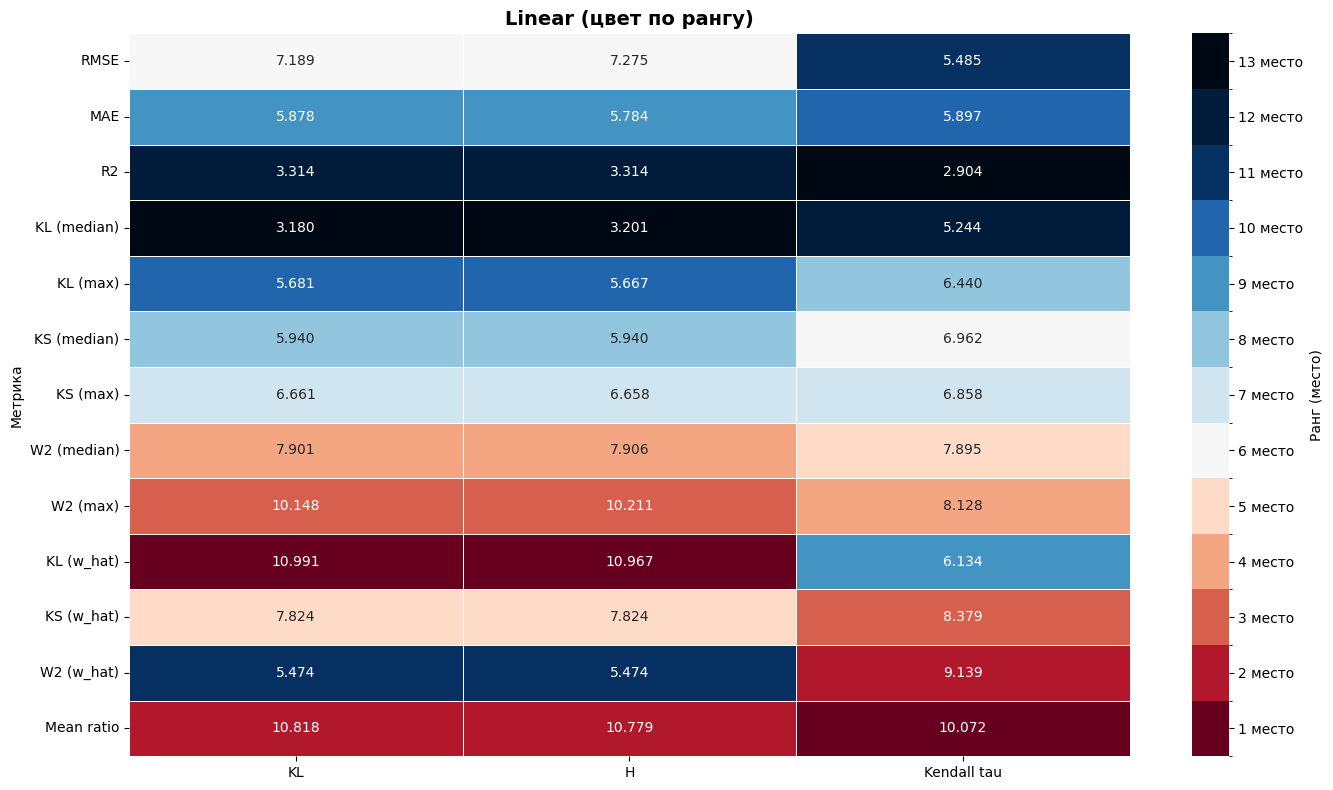

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Пример для нескольких наборов данных
data = {
    'Метрика': ['RMSE', 'MAE', 'R2', 'KL (median)', 'KL (max)', 
                'KS (median)', 'KS (max)', 'W2 (median)', 'W2 (max)',
                'KL (w_hat)', 'KS (w_hat)', 'W2 (w_hat)', 'Mean ratio'],
    'KL': vis[0],
    'H': vis[1],  # Пример
    'Kendall tau': vis[2]   # Пример
}

df = pd.DataFrame(data)
df.set_index('Метрика', inplace=True)

# Вычисляем ранги для определения цвета (но не меняем данные)
df_ranks = df.rank(axis=0, method='dense', ascending=False).astype(int)

# Создание тепловой карты
plt.figure(figsize=(14, 8))

# Используем дискретную цветовую карту с 13 цветами
colors = ['#67001f', '#b2182b', '#d6604d', '#f4a582', '#fddbc7',
          '#f7f7f7', '#d1e5f0', '#92c5de', '#4393c3', '#2166ac',
          '#053061', '#011c3a', '#000814']

# Создаем кастомную colormap
cmap = mcolors.ListedColormap(colors)

# Создаем нормализацию для дискретных значений от 1 до 13
bounds = np.arange(0.5, 14.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Создаем тепловую карту с исходными данными (df.values),
# но цвет определяется по рангам (df_ranks)
heatmap = sns.heatmap(df_ranks, annot=df.values, fmt='.3f', 
                      cmap=cmap, norm=norm,
                      linewidths=0.5, cbar_kws={'label': 'Ранг (место)'},
                      annot_kws={'size': 10})

# Настраиваем цветовую шкалу
cbar = heatmap.collections[0].colorbar
cbar.set_ticks(np.arange(1, 14))
cbar.set_ticklabels([f'{i} место' for i in range(1, 14)])

plt.title('Linear (цвет по рангу)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<font size="8"> RANDOM FOREST.</font>

<font size="4">ПРЕДОБРАБОТКА.</font>

In [42]:
rf = pd.read_csv('random_forest.csv')

In [43]:
rf['method_zapolnenia'] = rf['method_zapolnenia'].replace({'MEAN_MOD': 'MEAN_MODE', 'MED_MODE': 'MEDIAN_MODE', 'NUL_MOD': 'NUL_MODE'})

In [44]:
rf = rf.sort_values(
    by=['name_dataset', 'type_propusk', 'method_zapolnenia'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

In [45]:
rf = rf.drop(['model', 'RMSE', 'MAE', 'Accuracy', 'Precision', 'Recall', 'fit_time', 'time_score'], axis=1)

In [46]:
rf = rf.rename(columns={'R2': 'model_R2', 'F1': 'model_F1'})

In [47]:
result = pd.merge(file, rf, how='inner')

In [48]:
print(len(result))

6298


In [49]:
result.to_csv('analys_of_impute_rf.csv', index = False)

<font size="4">ПОДГОТОВКА К ТУРНИРУ, ПРИМЕНЯЕМ KL-ДИВЕРГЕНЦИЮ.</font>

In [50]:
# Загружаем данные
df = pd.read_csv('analys_of_impute_rf.csv')

# Создаем словари для хранения результатов
results_R2 = {}
results_F1 = {}

# Получаем уникальные комбинации type_propusk и name_dataset
unique_combinations = df[['type_propusk', 'name_dataset']].drop_duplicates()

print(f"Всего уникальных комбинаций: {len(unique_combinations)}")

# Для каждой уникальной комбинации
for idx, (type_propusk, dataset) in enumerate(unique_combinations.values):
    print(f"\nОбработка {idx+1}/{len(unique_combinations)}: type_propusk={type_propusk}, dataset={dataset}")
    
    # Фильтруем данные для текущей комбинации
    subset = df[(df['type_propusk'] == type_propusk) & (df['name_dataset'] == dataset)]
    
    if len(subset) == 0:
        print(f"  Нет данных для этой комбинации")
        continue
    
    # Получаем исходные столбцы (model_R2 и model_F1)
    original_R2 = subset['model_R2'].dropna()
    original_F1 = subset['model_F1'].dropna()
    
    # Создаем датафрейм с методами импутации
    imputed_methods = subset.set_index('method_zapolnenia')[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]

    # Если есть данные для R2
    if len(original_R2) > 0:
        print(f"  Вычисляем KL для model_R2 (n={len(original_R2)})...")
        kl_R2 = feature_wise_kl_single_vs_multi(original_R2, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_R2.items():
            key = (type_propusk, dataset, method, 'R2')
            results_R2[key] = kl_value
    
    # Если есть данные для F1
    if len(original_F1) > 0:
        print(f"  Вычисляем KL для model_F1 (n={len(original_F1)})...")
        kl_F1 = feature_wise_kl_single_vs_multi(original_F1, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_F1.items():
            key = (type_propusk, dataset, method, 'F1')
            results_F1[key] = kl_value

# Создаем итоговые датафреймы
print("\n" + "="*60)
print("СОЗДАНИЕ ИТОГОВЫХ ТАБЛИЦ")
print("="*60)

# Для R2
if results_R2:
    df_R2 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_R2.items()
    ])
    print(f"\nРезультаты для model_R2: {len(df_R2)} записей")
    print(df_R2.head(10))
else:
    print("\nНет результатов для model_R2")
    df_R2 = pd.DataFrame()

# Для F1
if results_F1:
    df_F1 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_F1.items()
    ])
    print(f"\nРезультаты для model_F1: {len(df_F1)} записей")
    print(df_F1.head(10))

else:
    print("\nНет результатов для model_F1")
    df_F1 = pd.DataFrame()

# Объединяем результаты в один датафрейм
if not df_R2.empty or not df_F1.empty:
    df_all = pd.concat([df_R2, df_F1], ignore_index=True)
    df_all.to_csv('kl_results_all_rf.csv', index=False)
    print("Все результаты сохранены в 'kl_results_all_rf.csv'")



Всего уникальных комбинаций: 1152

Обработка 1/1152: type_propusk=MAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 2/1152: type_propusk=MAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 3/1152: type_propusk=MAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 4/1152: type_propusk=MAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 5/1152: type_propusk=MCAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 6/1152: type_propusk=MCAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 7/1152: type_propusk=MCAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 8/1152: type_propusk=MCAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 9

<font size="4">ТУРНИР.</font>

In [18]:
data = pd.read_csv('kl_results_all_rf.csv')
data = data.drop(['metric_model'], axis = 1)
new_df_1 = data.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='metric_impute', 
                        values='kl_divergence').reset_index()

custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
new_df_1 = new_df_1.sort_values(
    by=['name_dataset', 'type_propusk'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

from scipy.stats import rankdata
import numpy as np

temp = new_df_1[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]
arr = np.array(temp)
# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_F = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)
# Средний ранг для каждого подхода
mean_ranks_F = ranks_F.mean(axis=0)
print("Матрица рангов:")
print(ranks_F)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_F[i]}')

Матрица рангов:
[[ 6  3  1 ... 11  5 12]
 [ 5  2  4 ...  6  7 12]
 [ 4  3  1 ... 11  8 13]
 ...
 [ 4  2  6 ...  9  8 12]
 [ 5  2  7 ...  9 10 12]
 [ 4  2  8 ...  7 10 12]]
Средние ранги подходов:
RMSE : 7.355902777777778
MAE : 5.934895833333333
R2 : 4.109375
KL_divergence_median : 3.4210069444444446
KL_divergence_max : 5.693576388888889
KS_statistic_median : 5.743923611111111
KS_statistic_max : 6.611111111111111
Wasserstein_2_median : 7.546006944444445
Wasserstein_2_max : 9.890625
kl_w_vs_w_hat : 10.91579861111111
ks_w_vs_w_hat : 7.598958333333333
wasserstein_2_w_vs_w_hat : 5.53125
mean_ratio : 10.647569444444445


In [19]:
vis = []
ar = []
for i in range(len(temp.columns)):
    ar.append(mean_ranks_F[i])
vis.append(ar)

<font size="4">ПОДГОТОВКА К ТУРНИРУ, ПРИМЕНЯЕМ КРОСС-ЭНТРОПИЮ.</font>

In [70]:
# Загружаем данные
df = pd.read_csv('analys_of_impute_rf.csv')

# Создаем словари для хранения результатов
results_R2 = {}
results_F1 = {}

# Получаем уникальные комбинации type_propusk и name_dataset
unique_combinations = df[['type_propusk', 'name_dataset']].drop_duplicates()

print(f"Всего уникальных комбинаций: {len(unique_combinations)}")

# Для каждой уникальной комбинации
for idx, (type_propusk, dataset) in enumerate(unique_combinations.values):
    print(f"\nОбработка {idx+1}/{len(unique_combinations)}: type_propusk={type_propusk}, dataset={dataset}")
    
    # Фильтруем данные для текущей комбинации
    subset = df[(df['type_propusk'] == type_propusk) & (df['name_dataset'] == dataset)]
    
    if len(subset) == 0:
        print(f"  Нет данных для этой комбинации")
        continue
    
    # Получаем исходные столбцы (model_R2 и model_F1)
    original_R2 = subset['model_R2'].dropna()
    original_F1 = subset['model_F1'].dropna()
    
    # Создаем датафрейм с методами импутации
    imputed_methods = subset.set_index('method_zapolnenia')[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]

    # Если есть данные для R2
    if len(original_R2) > 0:
        print(f"  Вычисляем KL для model_R2 (n={len(original_R2)})...")
        kl_R2 = feature_wise_cross_entropy_single_vs_multi(original_R2, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_R2.items():
            key = (type_propusk, dataset, method, 'R2')
            results_R2[key] = kl_value
    
    # Если есть данные для F1
    if len(original_F1) > 0:
        print(f"  Вычисляем KL для model_F1 (n={len(original_F1)})...")
        kl_F1 = feature_wise_cross_entropy_single_vs_multi(original_F1, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_F1.items():
            key = (type_propusk, dataset, method, 'F1')
            results_F1[key] = kl_value

# Создаем итоговые датафреймы
print("\n" + "="*60)
print("СОЗДАНИЕ ИТОГОВЫХ ТАБЛИЦ")
print("="*60)
# Для R2
if results_R2:
    df_R2 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_R2.items()
    ])
    print(f"\nРезультаты для model_R2: {len(df_R2)} записей")
    print(df_R2.head(10))
else:
    print("\nНет результатов для model_R2")
    df_R2 = pd.DataFrame()

# Для F1
if results_F1:
    df_F1 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_F1.items()
    ])
    print(f"\nРезультаты для model_F1: {len(df_F1)} записей")
    print(df_F1.head(10))
else:
    print("\nНет результатов для model_F1")
    df_F1 = pd.DataFrame()

# Объединяем результаты в один датафрейм
if not df_R2.empty or not df_F1.empty:
    df_all = pd.concat([df_R2, df_F1], ignore_index=True)
    df_all.to_csv('H_results_all_rf.csv', index=False)
    print("Все результаты сохранены в 'H_results_all_rf.csv'")


Всего уникальных комбинаций: 1152

Обработка 1/1152: type_propusk=MAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 2/1152: type_propusk=MAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 3/1152: type_propusk=MAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 4/1152: type_propusk=MAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 5/1152: type_propusk=MCAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 6/1152: type_propusk=MCAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 7/1152: type_propusk=MCAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 8/1152: type_propusk=MCAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 9

<font size="4">ТУРНИР.</font>

In [20]:
data = pd.read_csv('H_results_all_rf.csv')
data = data.drop(['metric_model'], axis = 1)
new_df_1 = data.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='metric_impute', 
                        values='kl_divergence').reset_index()
custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
new_df_1 = new_df_1.sort_values(
    by=['name_dataset', 'type_propusk'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

from scipy.stats import rankdata
import numpy as np

temp = new_df_1[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]
arr = np.array(temp)
# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_F = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)
# Средний ранг для каждого подхода
mean_ranks_F = ranks_F.mean(axis=0)
print("Матрица рангов:")
print(ranks_F)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_F[i]}')

Матрица рангов:
[[ 6  3  1 ... 11  5 12]
 [ 5  2  4 ...  6  7 12]
 [ 4  3  1 ... 11  8 13]
 ...
 [ 4  2  6 ...  9  8 12]
 [ 5  2  7 ...  9 10 12]
 [ 4  2  8 ...  7 10 12]]
Средние ранги подходов:
RMSE : 7.440104166666667
MAE : 5.839409722222222
R2 : 4.109375
KL_divergence_median : 3.4418402777777777
KL_divergence_max : 5.678819444444445
KS_statistic_median : 5.743923611111111
KS_statistic_max : 6.607638888888889
Wasserstein_2_median : 7.551215277777778
Wasserstein_2_max : 9.949652777777779
kl_w_vs_w_hat : 10.891493055555555
ks_w_vs_w_hat : 7.598958333333333
wasserstein_2_w_vs_w_hat : 5.53125
mean_ratio : 10.616319444444445


In [21]:
ar = []
for i in range(len(temp.columns)):
    ar.append(mean_ranks_F[i])
vis.append(ar)

<font size="4">ПОДГОТОВКА К ТУРНИРУ, ПРИМЕНЯЕМ Kendall tau.</font>

In [14]:
# Загружаем данные
df = pd.read_csv('analys_of_impute_rf.csv')

# Создаем словари для хранения результатов
results_R2 = {}
results_F1 = {}

# Получаем уникальные комбинации type_propusk и name_dataset
unique_combinations = df[['type_propusk', 'name_dataset']].drop_duplicates()

print(f"Всего уникальных комбинаций: {len(unique_combinations)}")

# Для каждой уникальной комбинации
for idx, (type_propusk, dataset) in enumerate(unique_combinations.values):
    print(f"\nОбработка {idx+1}/{len(unique_combinations)}: type_propusk={type_propusk}, dataset={dataset}")
    
    # Фильтруем данные для текущей комбинации
    subset = df[(df['type_propusk'] == type_propusk) & (df['name_dataset'] == dataset)]
    
    if len(subset) == 0:
        print(f"  Нет данных для этой комбинации")
        continue
    
    # Получаем исходные столбцы (model_R2 и model_F1)
    original_R2 = subset['model_R2'].dropna()
    original_F1 = subset['model_F1'].dropna()
    
    # Создаем датафрейм с методами импутации
    imputed_methods = subset.set_index('method_zapolnenia')[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]
    # Если есть данные для R2
    if len(original_R2) > 0:
        print(f"  Вычисляем KL для model_R2 (n={len(original_R2)})...")
        kl_R2 = feature_wise_kendall_tau_single_vs_multi(original_R2, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_R2.items():
            key = (type_propusk, dataset, method, 'R2')
            results_R2[key] = kl_value
    
    # Если есть данные для F1
    if len(original_F1) > 0:
        print(f"  Вычисляем KL для model_F1 (n={len(original_F1)})...")
        kl_F1 = feature_wise_kendall_tau_single_vs_multi(original_F1, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_F1.items():
            key = (type_propusk, dataset, method, 'F1')
            results_F1[key] = kl_value

# Создаем итоговые датафреймы
print("\n" + "="*60)
print("СОЗДАНИЕ ИТОГОВЫХ ТАБЛИЦ")
print("="*60)
# Для R2
if results_R2:
    df_R2 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_R2.items()
    ])
    print(f"\nРезультаты для model_R2: {len(df_R2)} записей")
    print(df_R2.head(10))
else:
    print("\nНет результатов для model_R2")
    df_R2 = pd.DataFrame()

# Для F1
if results_F1:
    df_F1 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_F1.items()
    ])
    print(f"\nРезультаты для model_F1: {len(df_F1)} записей")
    print(df_F1.head(10))

else:
    print("\nНет результатов для model_F1")
    df_F1 = pd.DataFrame()

# Объединяем результаты в один датафрейм
if not df_R2.empty or not df_F1.empty:
    df_all = pd.concat([df_R2, df_F1], ignore_index=True)
    df_all.to_csv('KT_results_all_rf.csv', index=False)
    print("Все результаты сохранены в KT_results_all_rf.csv'")



Всего уникальных комбинаций: 1152

Обработка 1/1152: type_propusk=MAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 2/1152: type_propusk=MAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 3/1152: type_propusk=MAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 4/1152: type_propusk=MAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 5/1152: type_propusk=MCAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 6/1152: type_propusk=MCAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 7/1152: type_propusk=MCAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 8/1152: type_propusk=MCAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 9

<font size="4">ТУРНИР.</font>

In [22]:
import pandas as pd

data = pd.read_csv('KT_results_all_rf.csv')
data = data.drop(['metric_model'], axis = 1)
new_df_1 = data.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='metric_impute', 
                        values='kl_divergence').reset_index()
custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
new_df_1 = new_df_1.sort_values(
    by=['name_dataset', 'type_propusk'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

from scipy.stats import rankdata
import numpy as np

temp = new_df_1[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                 'KL_divergence_max', 'KS_statistic_median', 
                 'KS_statistic_max', 'Wasserstein_2_median', 
                 'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                 'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                 'mean_ratio']]
ranks_df = pd.DataFrame(index=temp.index, columns=temp.columns)

# Для каждой строки (эксперимента) ранжируем методы импутации
for idx in temp.index:
    # Получаем значения всех методов для этого эксперимента
    values = temp.loc[idx].values
    
    # Ранжируем от лучшего (1) к худшему (13)
    # method='dense' для одинаковых значений
    # ascending=False так как большее значение = лучше
    ranks = pd.Series(values).rank(method='first', ascending=False).values
    
    # Сохраняем ранги
    ranks_df.loc[idx] = ranks

print("Матрица рангов:")
print(ranks_df)

# Средний ранг для каждого метода импутации (по всем экспериментам)
print("\nСредние ранги методов импутации (меньше = лучше):")
mean_ranks = ranks_df.mean().sort_values()
for method, rank in mean_ranks.items():
    print(f'{method}: {rank:.2f}')

Матрица рангов:
metric_impute  RMSE   MAE   R2 KL_divergence_median KL_divergence_max  \
0               5.0   6.0  1.0                  7.0               8.0   
1               7.0  11.0  1.0                 12.0              13.0   
2               3.0   4.0  1.0                  2.0               5.0   
3               5.0   6.0  2.0                  3.0               4.0   
4               5.0   6.0  1.0                 13.0               7.0   
...             ...   ...  ...                  ...               ...   
1046            8.0   6.0  1.0                  7.0              11.0   
1047           10.0  11.0  5.0                  7.0               8.0   
1048           12.0  13.0  1.0                  8.0               9.0   
1049           12.0   5.0  1.0                  8.0               9.0   
1050           11.0   6.0  1.0                  4.0               9.0   

metric_impute KS_statistic_median KS_statistic_max Wasserstein_2_median  \
0                             2.

In [23]:
ar = []
for method, rank in mean_ranks.items():
    ar.append(rank)
vis.append(ar)

In [50]:
vis = vis[:3]
vis

[[7.355902777777778,
  5.934895833333333,
  4.109375,
  3.4210069444444446,
  5.693576388888889,
  5.743923611111111,
  6.611111111111111,
  7.546006944444445,
  9.890625,
  10.91579861111111,
  7.598958333333333,
  5.53125,
  10.647569444444445],
 [7.440104166666667,
  5.839409722222222,
  4.109375,
  3.4418402777777777,
  5.678819444444445,
  5.743923611111111,
  6.607638888888889,
  7.551215277777778,
  9.949652777777779,
  10.891493055555555,
  7.598958333333333,
  5.53125,
  10.616319444444445],
 [4.330161750713606,
  5.002854424357754,
  5.78128078817734,
  5.884871550903901,
  6.221627408993576,
  6.687624750499002,
  6.89058039961941,
  6.937082936129647,
  7.7126546146527115,
  7.987630827783064,
  8.047236180904523,
  8.59372026641294,
  9.465271170313986]]

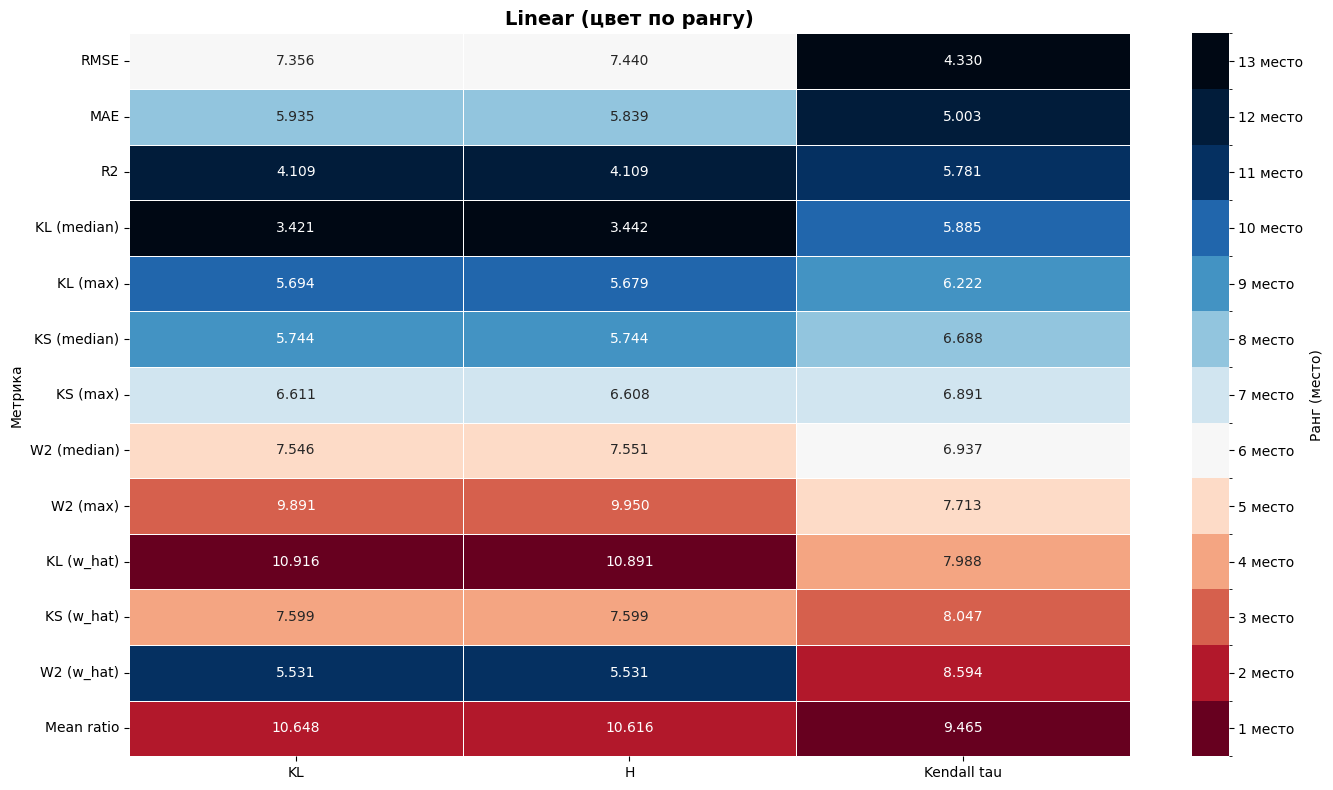

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Пример для нескольких наборов данных
data = {
    'Метрика': ['RMSE', 'MAE', 'R2', 'KL (median)', 'KL (max)', 
                'KS (median)', 'KS (max)', 'W2 (median)', 'W2 (max)',
                'KL (w_hat)', 'KS (w_hat)', 'W2 (w_hat)', 'Mean ratio'],
    'KL': vis[0],
    'H': vis[1],  # Пример
    'Kendall tau': vis[2]   # Пример
}

df = pd.DataFrame(data)
df.set_index('Метрика', inplace=True)

# Вычисляем ранги для определения цвета (но не меняем данные)
df_ranks = df.rank(axis=0, method='dense', ascending=False).astype(int)

# Создание тепловой карты
plt.figure(figsize=(14, 8))

# Используем дискретную цветовую карту с 13 цветами
colors = ['#67001f', '#b2182b', '#d6604d', '#f4a582', '#fddbc7',
          '#f7f7f7', '#d1e5f0', '#92c5de', '#4393c3', '#2166ac',
          '#053061', '#011c3a', '#000814']

# Создаем кастомную colormap
cmap = mcolors.ListedColormap(colors)

# Создаем нормализацию для дискретных значений от 1 до 13
bounds = np.arange(0.5, 14.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Создаем тепловую карту с исходными данными (df.values),
# но цвет определяется по рангам (df_ranks)
heatmap = sns.heatmap(df_ranks, annot=df.values, fmt='.3f', 
                      cmap=cmap, norm=norm,
                      linewidths=0.5, cbar_kws={'label': 'Ранг (место)'},
                      annot_kws={'size': 10})

# Настраиваем цветовую шкалу
cbar = heatmap.collections[0].colorbar
cbar.set_ticks(np.arange(1, 14))
cbar.set_ticklabels([f'{i} место' for i in range(1, 14)])

plt.title('Linear (цвет по рангу)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<font size="8"> XGBOOST.</font>

<font size="4">ПРЕДОБРАБОТКА.</font>

In [53]:
rf = pd.read_csv('xgboost.csv')

rf['method_zapolnenia'] = rf['method_zapolnenia'].replace({'MED_MODE': 'MEDIAN_MODE'})

rf = rf.sort_values(
    by=['name_dataset', 'type_propusk', 'method_zapolnenia'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

rf = rf.drop(['model', 'RMSE', 'MAE', 'Accuracy', 'Precision', 'Recall', 'fit_time', 'time_score'], axis=1)
rf = rf.rename(columns={'R2': 'model_R2', 'F1': 'model_F1'})

result = pd.merge(file, rf, how='inner')

print(len(result))

result = result.drop(['Unnamed: 0'], axis = 1)

result.to_csv('analys_of_impute_xgboost.csv', index = False)

6246


<font size="4">ПОДГОТОВКА К ТУРНИРУ, ПРИМЕНЯЕМ KL-ДИВЕРГЕНЦИЮ.</font>

In [54]:
# Загружаем данные
df = pd.read_csv('analys_of_impute_xgboost.csv')

# Создаем словари для хранения результатов
results_R2 = {}
results_F1 = {}

# Получаем уникальные комбинации type_propusk и name_dataset
unique_combinations = df[['type_propusk', 'name_dataset']].drop_duplicates()

print(f"Всего уникальных комбинаций: {len(unique_combinations)}")

# Для каждой уникальной комбинации
for idx, (type_propusk, dataset) in enumerate(unique_combinations.values):
    print(f"\nОбработка {idx+1}/{len(unique_combinations)}: type_propusk={type_propusk}, dataset={dataset}")
    
    # Фильтруем данные для текущей комбинации
    subset = df[(df['type_propusk'] == type_propusk) & (df['name_dataset'] == dataset)]
    
    if len(subset) == 0:
        print(f"  Нет данных для этой комбинации")
        continue
    
    # Получаем исходные столбцы (model_R2 и model_F1)
    original_R2 = subset['model_R2'].dropna()
    original_F1 = subset['model_F1'].dropna()
    
    # Создаем датафрейм с методами импутации
    imputed_methods = subset.set_index('method_zapolnenia')[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]

    # Если есть данные для R2
    if len(original_R2) > 0:
        print(f"  Вычисляем KL для model_R2 (n={len(original_R2)})...")
        kl_R2 = feature_wise_kl_single_vs_multi(original_R2, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_R2.items():
            key = (type_propusk, dataset, method, 'R2')
            results_R2[key] = kl_value
    
    # Если есть данные для F1
    if len(original_F1) > 0:
        print(f"  Вычисляем KL для model_F1 (n={len(original_F1)})...")
        kl_F1 = feature_wise_kl_single_vs_multi(original_F1, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_F1.items():
            key = (type_propusk, dataset, method, 'F1')
            results_F1[key] = kl_value

# Создаем итоговые датафреймы
print("\n" + "="*60)
print("СОЗДАНИЕ ИТОГОВЫХ ТАБЛИЦ")
print("="*60)

# Для R2
if results_R2:
    df_R2 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_R2.items()
    ])
    print(f"\nРезультаты для model_R2: {len(df_R2)} записей")
    print(df_R2.head(10))
else:
    print("\nНет результатов для model_R2")
    df_R2 = pd.DataFrame()

# Для F1
if results_F1:
    df_F1 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_F1.items()
    ])
    print(f"\nРезультаты для model_F1: {len(df_F1)} записей")
    print(df_F1.head(10))

else:
    print("\nНет результатов для model_F1")
    df_F1 = pd.DataFrame()

# Объединяем результаты в один датафрейм
if not df_R2.empty or not df_F1.empty:
    df_all = pd.concat([df_R2, df_F1], ignore_index=True)
    df_all.to_csv('kl_results_all_xgboost.csv', index=False)
    print("Все результаты сохранены в 'kl_results_all_xgboost.csv'")


Всего уникальных комбинаций: 1140

Обработка 1/1140: type_propusk=MAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 2/1140: type_propusk=MAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 3/1140: type_propusk=MAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 4/1140: type_propusk=MAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 5/1140: type_propusk=MCAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 6/1140: type_propusk=MCAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 7/1140: type_propusk=MCAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 8/1140: type_propusk=MCAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 9

<font size="4">ТУРНИР.</font>

In [25]:
data = pd.read_csv('kl_results_all_xgboost.csv')
data = data.drop(['metric_model'], axis = 1)
new_df_1 = data.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='metric_impute', 
                        values='kl_divergence').reset_index()

custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
new_df_1 = new_df_1.sort_values(
    by=['name_dataset', 'type_propusk'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

from scipy.stats import rankdata
import numpy as np

temp = new_df_1[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]
arr = np.array(temp)
# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_F = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)
# Средний ранг для каждого подхода
mean_ranks_F = ranks_F.mean(axis=0)
print("Матрица рангов:")
print(ranks_F)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_F[i]}')

Матрица рангов:
[[ 6  2  4 ... 11  5 12]
 [ 5  2  3 ...  6  7 12]
 [ 4  3  1 ... 11  8 13]
 ...
 [ 4  2  6 ...  9  8 12]
 [ 5  3  7 ...  8 10 12]
 [ 4  2  8 ...  7 10 12]]
Средние ранги подходов:
RMSE : 7.402631578947369
MAE : 5.77280701754386
R2 : 4.1421052631578945
KL_divergence_median : 3.1543859649122807
KL_divergence_max : 5.629824561403509
KS_statistic_median : 5.676315789473684
KS_statistic_max : 6.53421052631579
Wasserstein_2_median : 7.765789473684211
Wasserstein_2_max : 10.094736842105263
kl_w_vs_w_hat : 11.054385964912282
ks_w_vs_w_hat : 7.7
wasserstein_2_w_vs_w_hat : 5.328947368421052
mean_ratio : 10.743859649122808


In [26]:
vis = []
ar = []
for i in range(len(temp.columns)):
    ar.append(mean_ranks_F[i])
vis.append(ar)

<font size="4">ПОДГОТОВКА К ТУРНИРУ, ПРИМЕНЯЕМ КРОСС-ЭНТРОПИЮ.</font>

In [72]:
# Загружаем данные
df = pd.read_csv('analys_of_impute_xgboost.csv')

# Создаем словари для хранения результатов
results_R2 = {}
results_F1 = {}

# Получаем уникальные комбинации type_propusk и name_dataset
unique_combinations = df[['type_propusk', 'name_dataset']].drop_duplicates()

print(f"Всего уникальных комбинаций: {len(unique_combinations)}")

# Для каждой уникальной комбинации
for idx, (type_propusk, dataset) in enumerate(unique_combinations.values):
    print(f"\nОбработка {idx+1}/{len(unique_combinations)}: type_propusk={type_propusk}, dataset={dataset}")
    
    # Фильтруем данные для текущей комбинации
    subset = df[(df['type_propusk'] == type_propusk) & (df['name_dataset'] == dataset)]
    
    if len(subset) == 0:
        print(f"  Нет данных для этой комбинации")
        continue
    
    # Получаем исходные столбцы (model_R2 и model_F1)
    original_R2 = subset['model_R2'].dropna()
    original_F1 = subset['model_F1'].dropna()
    
    # Создаем датафрейм с методами импутации
    imputed_methods = subset.set_index('method_zapolnenia')[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]

    # Если есть данные для R2
    if len(original_R2) > 0:
        print(f"  Вычисляем KL для model_R2 (n={len(original_R2)})...")
        kl_R2 = feature_wise_cross_entropy_single_vs_multi(original_R2, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_R2.items():
            key = (type_propusk, dataset, method, 'R2')
            results_R2[key] = kl_value
    
    # Если есть данные для F1
    if len(original_F1) > 0:
        print(f"  Вычисляем KL для model_F1 (n={len(original_F1)})...")
        kl_F1 = feature_wise_cross_entropy_single_vs_multi(original_F1, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_F1.items():
            key = (type_propusk, dataset, method, 'F1')
            results_F1[key] = kl_value

# Создаем итоговые датафреймы
print("\n" + "="*60)
print("СОЗДАНИЕ ИТОГОВЫХ ТАБЛИЦ")
print("="*60)
# Для R2
if results_R2:
    df_R2 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_R2.items()
    ])
    print(f"\nРезультаты для model_R2: {len(df_R2)} записей")
    print(df_R2.head(10))
else:
    print("\nНет результатов для model_R2")
    df_R2 = pd.DataFrame()

# Для F1
if results_F1:
    df_F1 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_F1.items()
    ])
    print(f"\nРезультаты для model_F1: {len(df_F1)} записей")
    print(df_F1.head(10))
else:
    print("\nНет результатов для model_F1")
    df_F1 = pd.DataFrame()

# Объединяем результаты в один датафрейм
if not df_R2.empty or not df_F1.empty:
    df_all = pd.concat([df_R2, df_F1], ignore_index=True)
    df_all.to_csv('H_results_all_xgboost.csv', index=False)
    print("Все результаты сохранены в 'H_results_all_xgboost.csv'")


Всего уникальных комбинаций: 1140

Обработка 1/1140: type_propusk=MAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 2/1140: type_propusk=MAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 3/1140: type_propusk=MAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 4/1140: type_propusk=MAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 5/1140: type_propusk=MCAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 6/1140: type_propusk=MCAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 7/1140: type_propusk=MCAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 8/1140: type_propusk=MCAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 9

<font size="4">ТУРНИР.</font>

In [27]:
data = pd.read_csv('H_results_all_xgboost.csv')
data = data.drop(['metric_model'], axis = 1)
new_df_1 = data.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='metric_impute', 
                        values='kl_divergence').reset_index()
custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
new_df_1 = new_df_1.sort_values(
    by=['name_dataset', 'type_propusk'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

from scipy.stats import rankdata
import numpy as np

temp = new_df_1[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]
arr = np.array(temp)
# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_F = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)
# Средний ранг для каждого подхода
mean_ranks_F = ranks_F.mean(axis=0)
print("Матрица рангов:")
print(ranks_F)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_F[i]}')

Матрица рангов:
[[ 6  2  4 ... 11  5 12]
 [ 5  2  3 ...  6  7 12]
 [ 4  3  1 ... 11  8 13]
 ...
 [ 4  2  6 ...  9  8 12]
 [ 5  3  7 ...  8 10 12]
 [ 4  2  8 ...  7 10 12]]
Средние ранги подходов:
RMSE : 7.492105263157895
MAE : 5.67719298245614
R2 : 4.1421052631578945
KL_divergence_median : 3.175438596491228
KL_divergence_max : 5.614035087719298
KS_statistic_median : 5.676315789473684
KS_statistic_max : 6.532456140350877
Wasserstein_2_median : 7.771052631578947
Wasserstein_2_max : 10.151754385964912
kl_w_vs_w_hat : 11.028947368421052
ks_w_vs_w_hat : 7.7
wasserstein_2_w_vs_w_hat : 5.328947368421052
mean_ratio : 10.709649122807017


In [28]:
ar = []
for i in range(len(temp.columns)):
    ar.append(mean_ranks_F[i])
vis.append(ar)

<font size="4">ПОДГОТОВКА К ТУРНИРУ, ПРИМЕНЯЕМ Kendall tau.</font>

In [16]:
# Загружаем данные
df = pd.read_csv('analys_of_impute_xgboost.csv')

# Создаем словари для хранения результатов
results_R2 = {}
results_F1 = {}

# Получаем уникальные комбинации type_propusk и name_dataset
unique_combinations = df[['type_propusk', 'name_dataset']].drop_duplicates()

print(f"Всего уникальных комбинаций: {len(unique_combinations)}")

# Для каждой уникальной комбинации
for idx, (type_propusk, dataset) in enumerate(unique_combinations.values):
    print(f"\nОбработка {idx+1}/{len(unique_combinations)}: type_propusk={type_propusk}, dataset={dataset}")
    
    # Фильтруем данные для текущей комбинации
    subset = df[(df['type_propusk'] == type_propusk) & (df['name_dataset'] == dataset)]
    
    if len(subset) == 0:
        print(f"  Нет данных для этой комбинации")
        continue
    
    # Получаем исходные столбцы (model_R2 и model_F1)
    original_R2 = subset['model_R2'].dropna()
    original_F1 = subset['model_F1'].dropna()
    
    # Создаем датафрейм с методами импутации
    imputed_methods = subset.set_index('method_zapolnenia')[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                                                              'KL_divergence_max', 'KS_statistic_median', 
                                                              'KS_statistic_max', 'Wasserstein_2_median', 
                                                              'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                                                              'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                                                              'mean_ratio']]

    # Если есть данные для R2
    if len(original_R2) > 0:
        print(f"  Вычисляем KL для model_R2 (n={len(original_R2)})...")
        kl_R2 = feature_wise_kendall_tau_single_vs_multi(original_R2, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_R2.items():
            key = (type_propusk, dataset, method, 'R2')
            results_R2[key] = kl_value
    
    # Если есть данные для F1
    if len(original_F1) > 0:
        print(f"  Вычисляем KL для model_F1 (n={len(original_F1)})...")
        kl_F1 = feature_wise_kendall_tau_single_vs_multi(original_F1, imputed_methods)
        
        # Сохраняем результаты
        for method, kl_value in kl_F1.items():
            key = (type_propusk, dataset, method, 'F1')
            results_F1[key] = kl_value

# Создаем итоговые датафреймы
print("\n" + "="*60)
print("СОЗДАНИЕ ИТОГОВЫХ ТАБЛИЦ")
print("="*60)
# Для R2
if results_R2:
    df_R2 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_R2.items()
    ])
    print(f"\nРезультаты для model_R2: {len(df_R2)} записей")
    print(df_R2.head(10))
else:
    print("\nНет результатов для model_R2")
    df_R2 = pd.DataFrame()

# Для F1
if results_F1:
    df_F1 = pd.DataFrame([
        {
            'type_propusk': key[0],
            'name_dataset': key[1],
            'metric_impute': key[2],
            'metric_model': key[3],
            'kl_divergence': value
        }
        for key, value in results_F1.items()
    ])
    print(f"\nРезультаты для model_F1: {len(df_F1)} записей")
    print(df_F1.head(10))

else:
    print("\nНет результатов для model_F1")
    df_F1 = pd.DataFrame()

# Объединяем результаты в один датафрейм
if not df_R2.empty or not df_F1.empty:
    df_all = pd.concat([df_R2, df_F1], ignore_index=True)
    df_all.to_csv('KT_results_all_xgboost.csv', index=False)
    print("Все результаты сохранены в KT_results_all_xgboost.csv'")



Всего уникальных комбинаций: 1140

Обработка 1/1140: type_propusk=MAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 2/1140: type_propusk=MAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 3/1140: type_propusk=MAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 4/1140: type_propusk=MAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 5/1140: type_propusk=MCAR_5, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 6/1140: type_propusk=MCAR_15, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=6)...

Обработка 7/1140: type_propusk=MCAR_30, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 8/1140: type_propusk=MCAR_50, dataset=2dplanes_binclass_binaryClass.csv
  Вычисляем KL для model_F1 (n=5)...

Обработка 9

<font size="4">ТУРНИР.</font>

In [29]:
import pandas as pd

data = pd.read_csv('KT_results_all_xgboost.csv')
data = data.drop(['metric_model'], axis = 1)
new_df_1 = data.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='metric_impute', 
                        values='kl_divergence').reset_index()
custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
new_df_1 = new_df_1.sort_values(
    by=['name_dataset', 'type_propusk'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
).reset_index(drop=True)

from scipy.stats import rankdata
import numpy as np

temp = new_df_1[['RMSE', 'MAE', 'R2', 'KL_divergence_median', 
                 'KL_divergence_max', 'KS_statistic_median', 
                 'KS_statistic_max', 'Wasserstein_2_median', 
                 'Wasserstein_2_max', 'kl_w_vs_w_hat', 
                 'ks_w_vs_w_hat', 'wasserstein_2_w_vs_w_hat', 
                 'mean_ratio']]
ranks_df = pd.DataFrame(index=temp.index, columns=temp.columns)

# Для каждой строки (эксперимента) ранжируем методы импутации
for idx in temp.index:
    # Получаем значения всех методов для этого эксперимента
    values = temp.loc[idx].values
    
    # Ранжируем от лучшего (1) к худшему (13)
    # method='dense' для одинаковых значений
    # ascending=False так как большее значение = лучше
    ranks = pd.Series(values).rank(method='first', ascending=False).values
    
    # Сохраняем ранги
    ranks_df.loc[idx] = ranks

print("Матрица рангов:")
print(ranks_df)

# Средний ранг для каждого метода импутации (по всем экспериментам)
print("\nСредние ранги методов импутации (меньше = лучше):")
mean_ranks = ranks_df.mean().sort_values()
for method, rank in mean_ranks.items():
    print(f'{method}: {rank:.2f}')

Матрица рангов:
metric_impute  RMSE   MAE    R2 KL_divergence_median KL_divergence_max  \
0               6.0   7.0   1.0                  2.0               8.0   
1               7.0  11.0   1.0                 13.0              12.0   
2               3.0   4.0   1.0                  2.0               5.0   
3               4.0   5.0   2.0                  3.0              13.0   
4               5.0   6.0   1.0                 13.0               7.0   
...             ...   ...   ...                  ...               ...   
1127           10.0   3.0   1.0                  5.0               6.0   
1128            5.0   6.0  11.0                  1.0               8.0   
1129            4.0   5.0   2.0                  9.0              10.0   
1130           12.0   5.0   6.0                  8.0               9.0   
1131           10.0  11.0   1.0                  6.0               7.0   

metric_impute KS_statistic_median KS_statistic_max Wasserstein_2_median  \
0                   

In [30]:
ar = []
for method, rank in mean_ranks.items():
    ar.append(rank)
vis.append(ar)

In [58]:
vis

[[7.402631578947369,
  5.77280701754386,
  4.1421052631578945,
  3.1543859649122807,
  5.629824561403509,
  5.676315789473684,
  6.53421052631579,
  7.765789473684211,
  10.094736842105263,
  11.054385964912282,
  7.7,
  5.328947368421052,
  10.743859649122808],
 [7.492105263157895,
  5.67719298245614,
  4.1421052631578945,
  3.175438596491228,
  5.614035087719298,
  5.676315789473684,
  6.532456140350877,
  7.771052631578947,
  10.151754385964912,
  11.028947368421052,
  7.7,
  5.328947368421052,
  10.709649122807017],
 [4.234982332155477,
  5.1916961130742045,
  5.684354986276304,
  5.91696113074205,
  6.332665330661323,
  6.8020351526364475,
  7.069787985865724,
  7.185840707964601,
  7.597173144876325,
  7.651060070671378,
  8.192558139534883,
  8.378091872791519,
  9.302120141342757]]

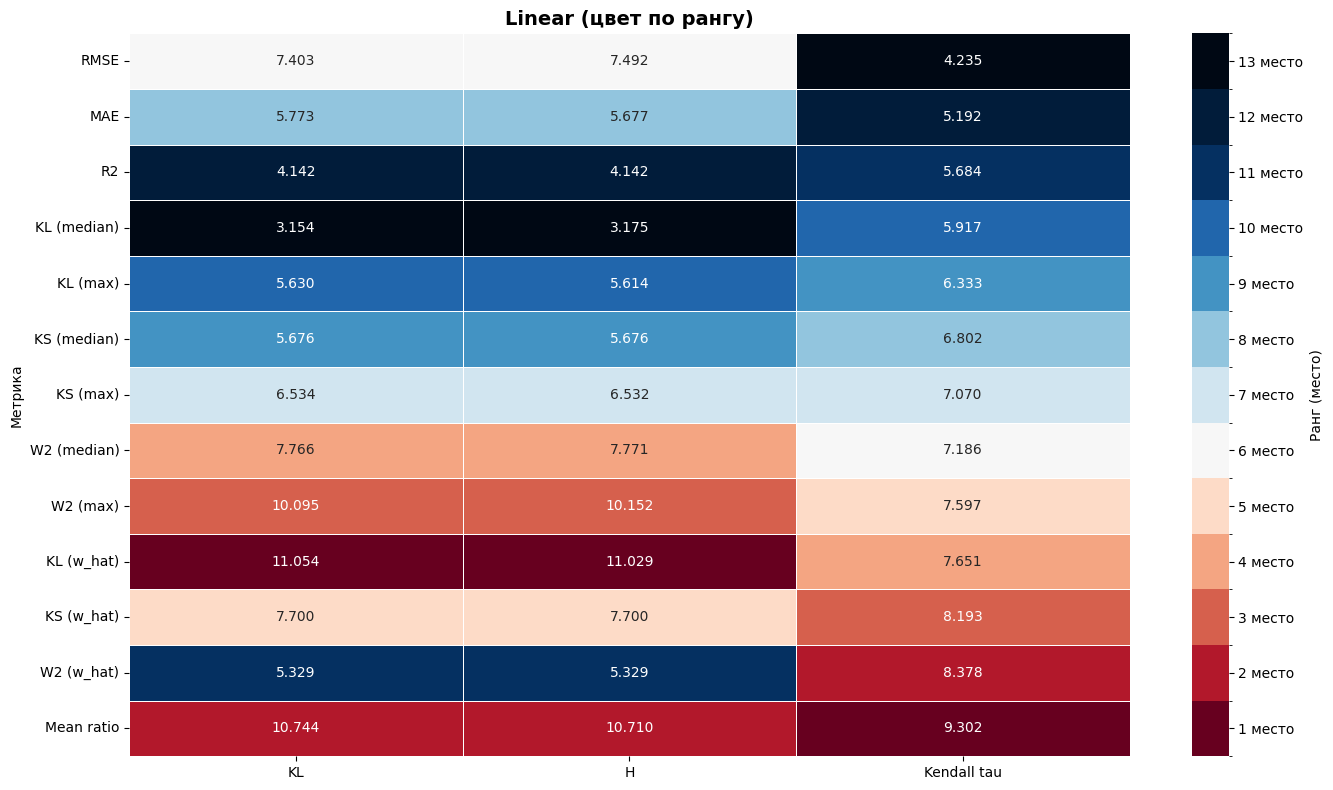

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Пример для нескольких наборов данных
data = {
    'Метрика': ['RMSE', 'MAE', 'R2', 'KL (median)', 'KL (max)', 
                'KS (median)', 'KS (max)', 'W2 (median)', 'W2 (max)',
                'KL (w_hat)', 'KS (w_hat)', 'W2 (w_hat)', 'Mean ratio'],
    'KL': vis[0],
    'H': vis[1],  # Пример
    'Kendall tau': vis[2]   # Пример
}

df = pd.DataFrame(data)
df.set_index('Метрика', inplace=True)

# Вычисляем ранги для определения цвета (но не меняем данные)
df_ranks = df.rank(axis=0, method='dense', ascending=False).astype(int)

# Создание тепловой карты
plt.figure(figsize=(14, 8))

# Используем дискретную цветовую карту с 13 цветами
colors = ['#67001f', '#b2182b', '#d6604d', '#f4a582', '#fddbc7',
          '#f7f7f7', '#d1e5f0', '#92c5de', '#4393c3', '#2166ac',
          '#053061', '#011c3a', '#000814']

# Создаем кастомную colormap
cmap = mcolors.ListedColormap(colors)

# Создаем нормализацию для дискретных значений от 1 до 13
bounds = np.arange(0.5, 14.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Создаем тепловую карту с исходными данными (df.values),
# но цвет определяется по рангам (df_ranks)
heatmap = sns.heatmap(df_ranks, annot=df.values, fmt='.3f', 
                      cmap=cmap, norm=norm,
                      linewidths=0.5, cbar_kws={'label': 'Ранг (место)'},
                      annot_kws={'size': 10})

# Настраиваем цветовую шкалу
cbar = heatmap.collections[0].colorbar
cbar.set_ticks(np.arange(1, 14))
cbar.set_ticklabels([f'{i} место' for i in range(1, 14)])

plt.title('Linear (цвет по рангу)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()